# Depth of Focus

This notebook compares the depth of focus between an optimized diffractive cascade and a conventional Fresnel zone plate (FZP). It loads focal plane intensity sweeps along the optical axis (z-sweep) and plots the transverse intensity profiles at various defocus positions to show how the optimized design maintains focus over a larger axial range.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy
from matplotlib.ticker import ScalarFormatter

In [2]:
import sys
from pathlib import Path

repo_root = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(repo_root))

from src.util import airy_1d_intensity, gaussian_energy_spectrum
from src.simparams import SimParams

In [3]:
matplotlib.rcParams['figure.dpi'] = 200
matplotlib.rcParams.update({'font.size': 24})

## Load data and set up simulation grid

Load the focal sweep comparison results. This includes z-axis intensity sweeps for three configurations: a Fresnel zone plate, a single-plane optimized cascade, and a multi-plane (extended depth of focus) optimized cascade.

In [4]:
path = repo_root / "paper_data"
params = np.load(path / "fig4b_xray_focusing_focal_sweep_comparison_params.npy", allow_pickle=True).item()
results = np.load(path / "fig4b_xray_focusing_focal_sweep_comparison_results.npz", allow_pickle=True)

In [5]:
opt_intensity_z_sweep = results['opt_intensity_run1_z_sweep']
opt_intensity = opt_intensity_z_sweep[:, opt_intensity_z_sweep.shape[1]//2]
exdof_intensity_z_sweep = results['opt_intensity_run2_z_sweep']
exdof_intensity = exdof_intensity_z_sweep[:, exdof_intensity_z_sweep.shape[1]//2]
fzp_intensity = results["zp_intensity"]
fzp_intensity_z_sweep = results["zp_intensity_z_sweep"]

In [6]:
Nx = params["Nx"]

lams, weights = gaussian_energy_spectrum(
    central_energy_ev = params['central_energy_ev'],
    N = params['N_wvl'],
    bandwidth = params['bandwidth'],
    device = "cpu",
    bandwidth_in_wavelength = False
)

sim_params = SimParams(
    Ny = 1, 
    Nx = Nx,
    dx = params["dx"],
    device="cpu",
    dtype = torch.complex128,
    lams = lams, 
    weights = weights
)
x = sim_params.x.cpu()

In [7]:
opt_efficiency = results["opt_efficiency"]

In [8]:
x_upsample = np.linspace(x.min(), x.max(), int(20*Nx))

opt_cs = scipy.interpolate.CubicSpline(x, opt_intensity)
fzp_cs = scipy.interpolate.CubicSpline(x, fzp_intensity)
exdof_cs = scipy.interpolate.CubicSpline(x, exdof_intensity)

opt_intensity_upsample = opt_cs(x_upsample)
fzp_intensity_upsample = fzp_cs(x_upsample)
exdof_intensity_upsample = exdof_cs(x_upsample)

airy_intensity = airy_1d_intensity(x_upsample, params["min_feature_size"])*opt_intensity_upsample.max()

In [9]:
upsample = 10
crop = Nx*upsample//2 - 1500

maps = [fzp_intensity_z_sweep, opt_intensity_z_sweep, exdof_intensity_z_sweep]
maps_upsample = []

x_upsample = np.linspace(x.min(), x.max(), int(upsample*Nx - 1))
x_upsample_crop = x_upsample[crop:x_upsample.shape[0]-crop]

for mapi in maps:
    mapi_upsample = np.zeros((x_upsample_crop.shape[0], mapi.shape[1]))
    for i in range(mapi.shape[1]):
    
        cs = scipy.interpolate.CubicSpline(x, mapi[:, i])
    
        intensity_upsample = cs(x_upsample)
        intensity_upsample_crop = intensity_upsample[crop:x_upsample.shape[0]-crop]
        mapi_upsample[:, i] = intensity_upsample_crop
    
    maps_upsample.append(mapi_upsample)

In [10]:
z_distances = results["z_eval"]
z_distances_zero = z_distances - z_distances[len(z_distances) // 2]
Z, X = np.meshgrid(z_distances_zero, x_upsample_crop)

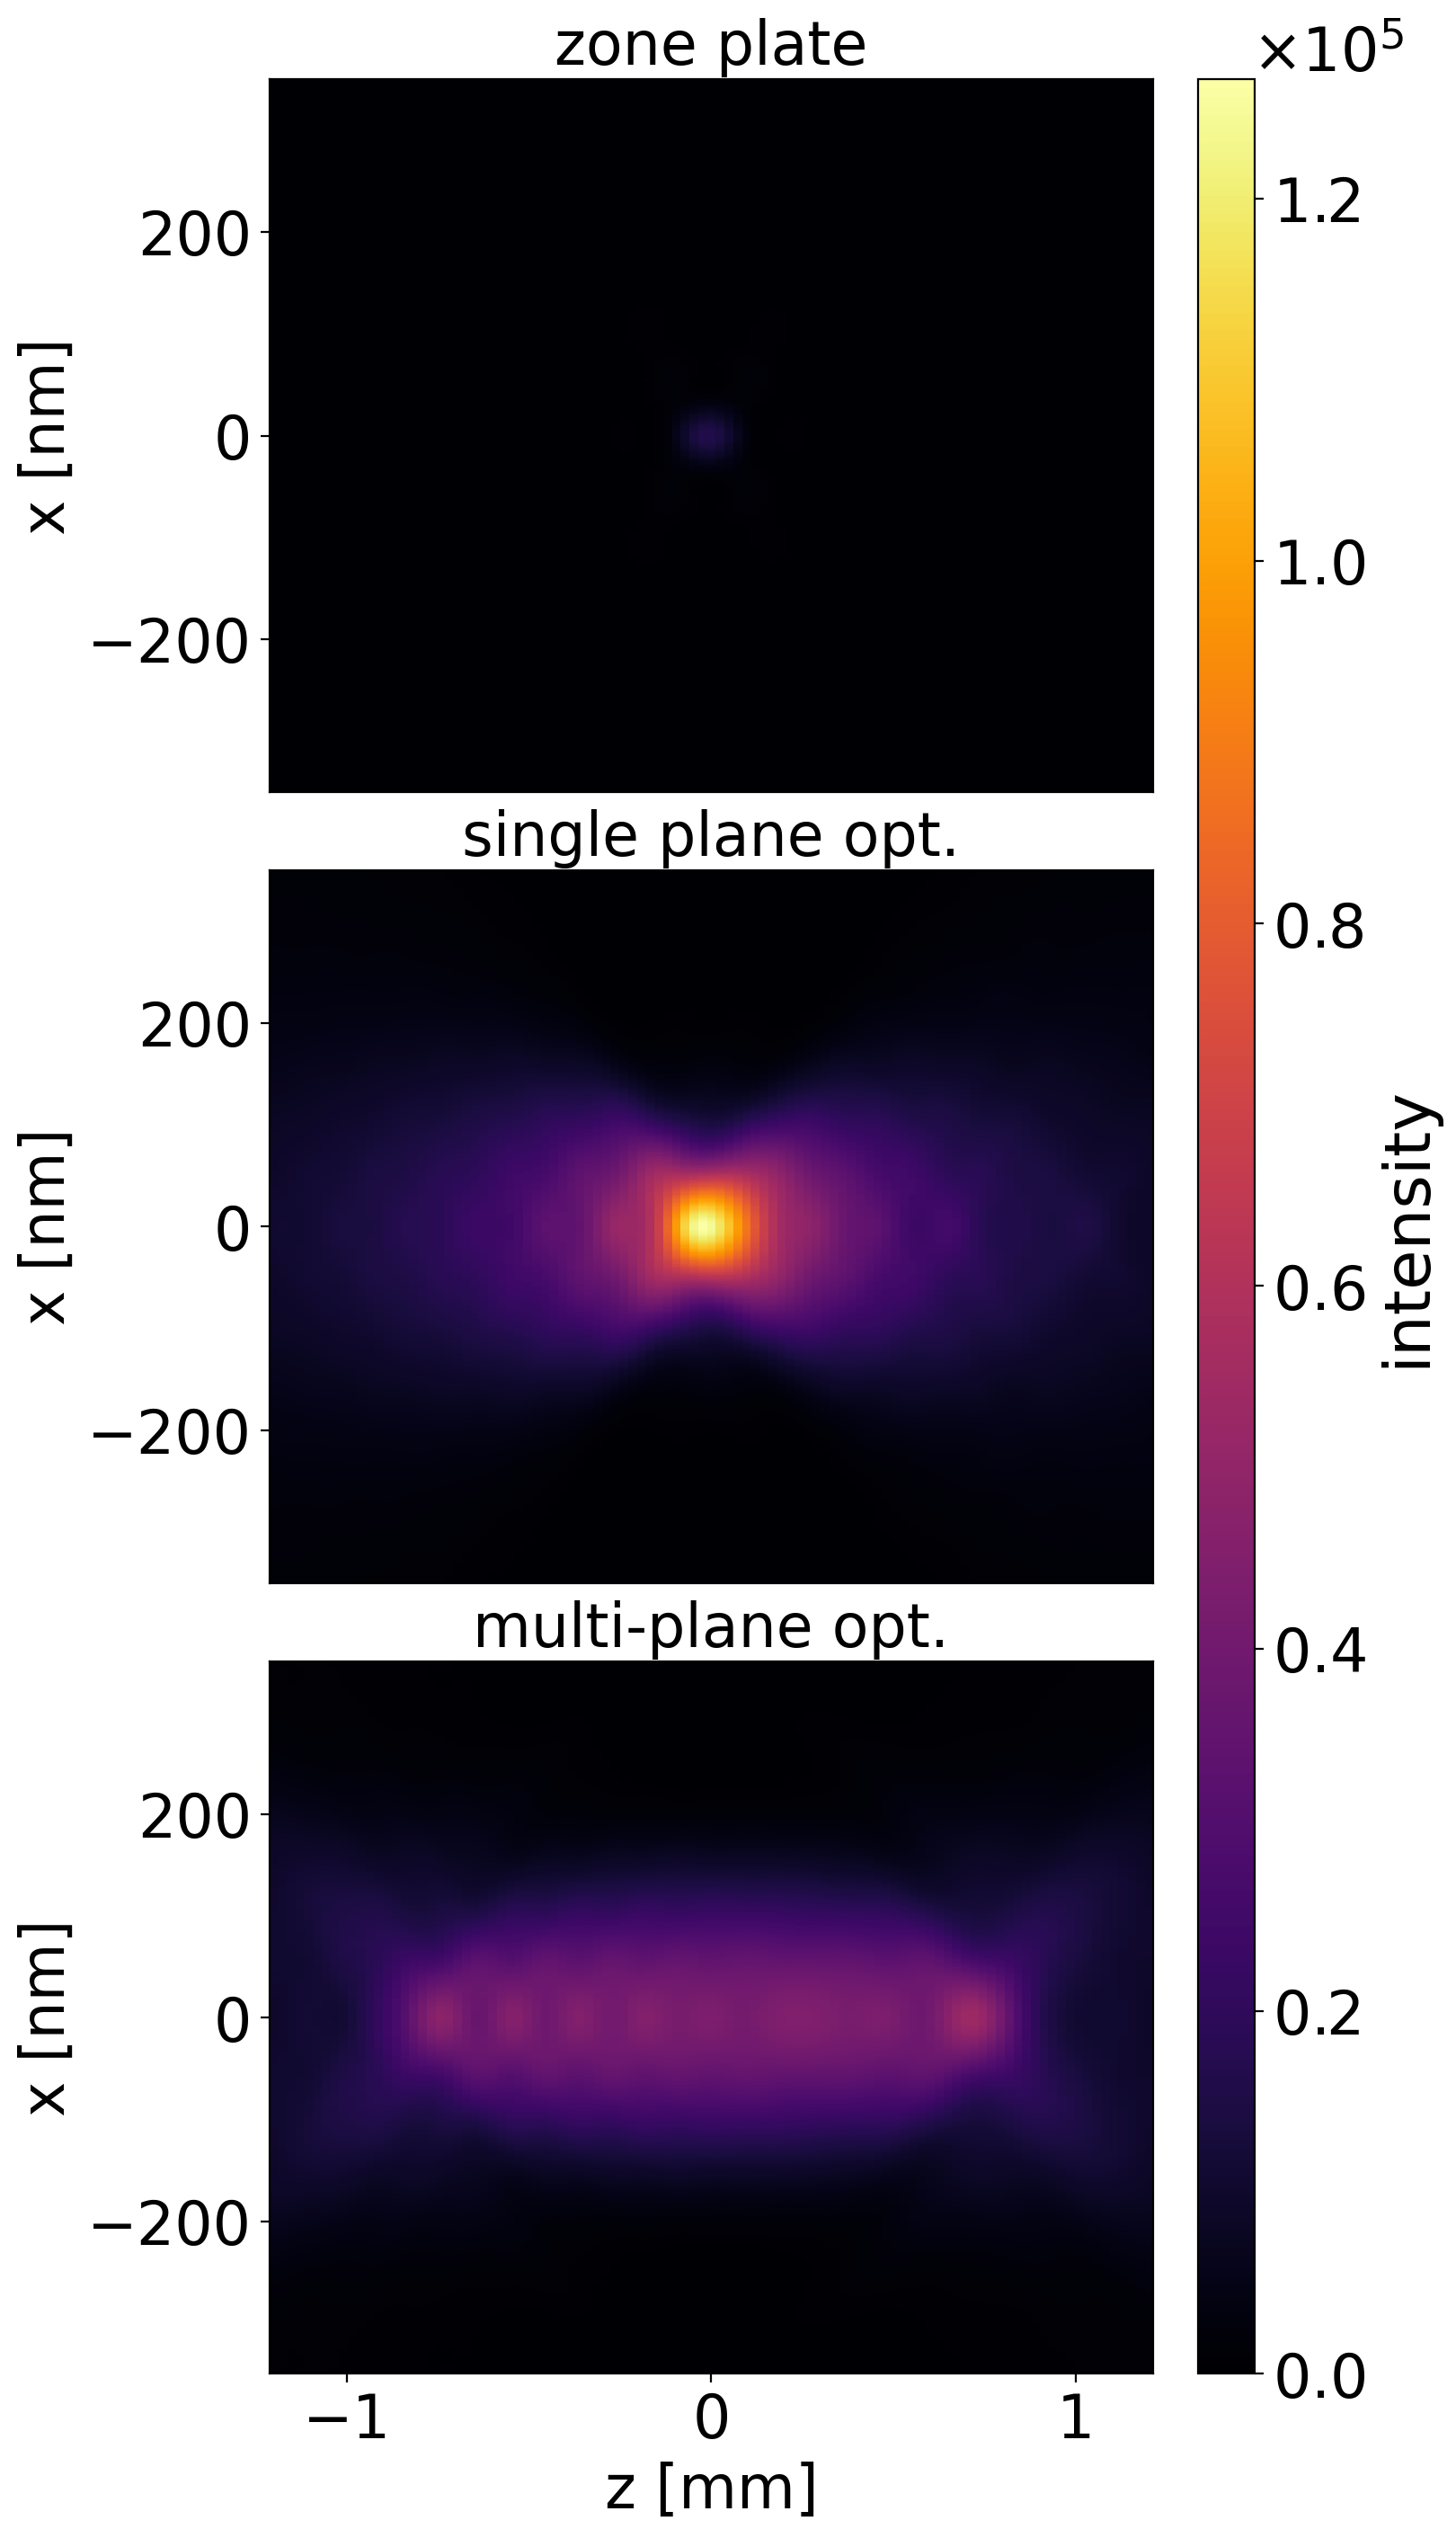

In [11]:
max_val = max([mapi.max() for mapi in maps_upsample])
titles = ['zone plate', 'single plane opt.', 'multi-plane opt.']

fig, axes = plt.subplots(3, 1, figsize=(8, 14), sharex=True, constrained_layout=True)

for i, ax in enumerate(axes):
    im = ax.pcolormesh(Z*1e3, X*1e9, maps_upsample[i], shading='auto', vmin=0.0, vmax=max_val, cmap='inferno')
    # ax.axvline(0, color='red', linestyle='--')
    
    ax.set_title(titles[i], fontsize=24)
    ax.set_ylim(-350, 350)
    
    ax.set_ylabel('x [nm]', fontsize=24)
    
    if i == 2:
        ax.set_xlabel('z [mm]', fontsize=24)
    else:
        ax.xaxis.set_visible(False)

cbar = fig.colorbar(im, ax=axes, label='intensity', aspect=40)
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))
cbar.formatter = formatter
cbar.update_ticks()
cbar.ax.yaxis.get_offset_text().set_x(3.6)

cbar.set_label('intensity', fontsize=26)

plt.show()